In [11]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import EoN
from tqdm import trange
import pandas as pd
import shutil
import random
from sklearn.model_selection import train_test_split

from pathlib import Path

DATA_ROOT = Path('data')
SIM_ROOT = DATA_ROOT / 'simulations'
META_DIR = DATA_ROOT / 'meta'
SPLITS_ROOT = DATA_ROOT / 'splits'
RUNS_CSV = META_DIR / 'runs.csv'
for _d in (SIM_ROOT, META_DIR, SPLITS_ROOT / 'train', SPLITS_ROOT / 'val', SPLITS_ROOT / 'test'):
    _d.mkdir(parents=True, exist_ok=True)


In [12]:
def SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam, t_stream=30):
    """SEIR на графе с внешним импортом: каждый день число новых E ~ Poisson(lam) среди узлов,
    которые в начале дня были восприимчивы (S). Сетевые переходы считаются по тем же состояниям."""
    for node in G.nodes():
        G.nodes[node]['state'] = 0

    susceptible_count = []
    exposed_count = []
    infected_count = []
    recovered_count = []

    for day in range(tmax + 1):
        new_states = {}

        susceptible = sum(1 for n in G.nodes if G.nodes[n]['state'] == 0)
        exposed = sum(1 for n in G.nodes if G.nodes[n]['state'] == 1)
        infected = sum(1 for n in G.nodes if G.nodes[n]['state'] == 2)
        recovered = sum(1 for n in G.nodes if G.nodes[n]['state'] == 3)

        susceptible_count.append(susceptible)
        exposed_count.append(exposed)
        infected_count.append(infected)
        recovered_count.append(recovered)

        if day < t_stream:
            susceptibles = [n for n in G.nodes if G.nodes[n]['state'] == 0]
            k = np.random.poisson(lam)
            if k > 0 and susceptibles:
                k = min(int(k), len(susceptibles))
                for node in random.sample(susceptibles, k):
                    new_states[node] = 1

        for node in G.nodes():
            state = G.nodes[node]['state']
            if state == 2:
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]['state'] == 0:
                        if random.random() < tau:
                            new_states[neighbor] = 1
                if random.random() < gamma:
                    new_states[node] = 3
            elif state == 1:
                if random.random() < alpha:
                    new_states[node] = 2

        for node, new_state in new_states.items():
            G.nodes[node]['state'] = new_state

    return [index for index in range(tmax + 1)], susceptible_count, exposed_count, infected_count, recovered_count


# barabasi_albert_graph

In [14]:
# parameters for the network

N = 10**4

G = nx.barabasi_albert_graph(N, 5)
#G = nx.complete_graph(N)
#G = nx.watts_strogatz_graph(N, 8, 0.1)
#G = nx.complete_graph(N)

tmax = 100
iterations = 50  # run 50 simulations
tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
gamma = 0.08  # recovery rate
alpha = 0.1 # latent period rate
lam_boundaries = 2 ** np.arange(0, 6, 1)
GRAPH_KIND = 'barabasi_albert_graph'
graph_out = SIM_ROOT / GRAPH_KIND
if graph_out.exists():
    shutil.rmtree(graph_out)
graph_out.mkdir(parents=True, exist_ok=True)
if RUNS_CSV.exists():
    old_runs = pd.read_csv(RUNS_CSV)
    old_runs = old_runs[old_runs["graph_kind"] != GRAPH_KIND].reset_index(drop=True)
else:
    old_runs = pd.DataFrame()
for _lam in lam_boundaries:
    (graph_out / f'lam={int(_lam)}').mkdir(parents=True, exist_ok=True)
run_rows = []
seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        print('---')
        lam_dir = SIM_ROOT / GRAPH_KIND / f'lam={int(lam)}'
        lam_dir.mkdir(parents=True, exist_ok=True)
        for iter in range(0, 50):
            t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam)

            S = np.array(S)
            E = np.array(E)
            I = np.array(I)
            R = np.array(R)

            beta_values = []
            num_days = len(t)
            for j in range(num_days - 1):
                if S[j] > 0 and I[j] > 0:
                    beta = - (S[j + 1] - S[j]) / (S[j] * I[j])
                else:
                    beta = np.nan
                beta_values.append(beta)
            beta_values.append(np.nan)
            df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
            output_file = f"seir_seed_{seed}.csv"
            out_path = lam_dir / output_file
            df_sim.to_csv(out_path, index=False)
            rel = (Path('simulations') / GRAPH_KIND / f'lam={int(lam)}' / output_file).as_posix()
            run_rows.append({
                "relative_path": rel,
                "graph_kind": GRAPH_KIND,
                "lam": float(lam),
                "tau": float(tau),
                "seed_in_graph": int(seed),
            })
            print(seed)
            seed += 1

new_df = pd.DataFrame(run_rows)
combined = pd.concat([old_runs, new_df], ignore_index=True).drop_duplicates(
    subset=["relative_path"], keep="last"
)
combined.to_csv(RUNS_CSV, index=False)
print('END')


---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

# complete_graph

In [ ]:
G = nx.complete_graph(N)
GRAPH_KIND = 'complete_graph'
graph_out = SIM_ROOT / GRAPH_KIND
if graph_out.exists():
    shutil.rmtree(graph_out)
graph_out.mkdir(parents=True, exist_ok=True)
if RUNS_CSV.exists():
    old_runs = pd.read_csv(RUNS_CSV)
    old_runs = old_runs[old_runs["graph_kind"] != GRAPH_KIND].reset_index(drop=True)
else:
    old_runs = pd.DataFrame()
for _lam in lam_boundaries:
    (graph_out / f'lam={int(_lam)}').mkdir(parents=True, exist_ok=True)
run_rows = []
seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        print('---')
        lam_dir = SIM_ROOT / GRAPH_KIND / f'lam={int(lam)}'
        lam_dir.mkdir(parents=True, exist_ok=True)
        for iter in range(0, 5):
            t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam)

            S = np.array(S)
            E = np.array(E)
            I = np.array(I)
            R = np.array(R)

            beta_values = []
            num_days = len(t)
            for j in range(num_days - 1):
                if S[j] > 0 and I[j] > 0:
                    beta = - (S[j + 1] - S[j]) / (S[j] * I[j])
                else:
                    beta = np.nan
                beta_values.append(beta)
            beta_values.append(np.nan)
            df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
            output_file = f"seir_seed_{seed}.csv"
            out_path = lam_dir / output_file
            df_sim.to_csv(out_path, index=False)
            rel = (Path('simulations') / GRAPH_KIND / f'lam={int(lam)}' / output_file).as_posix()
            run_rows.append({
                "relative_path": rel,
                "graph_kind": GRAPH_KIND,
                "lam": float(lam),
                "tau": float(tau),
                "seed_in_graph": int(seed),
            })
            print(seed)
            seed += 1

new_df = pd.DataFrame(run_rows)
combined = pd.concat([old_runs, new_df], ignore_index=True).drop_duplicates(
    subset=["relative_path"], keep="last"
)
combined.to_csv(RUNS_CSV, index=False)
print('END')


# watts_strogatz_graph

In [22]:
G = nx.watts_strogatz_graph(N, 8, 0.1)
GRAPH_KIND = 'watts_strogatz_graph'
graph_out = SIM_ROOT / GRAPH_KIND
if graph_out.exists():
    shutil.rmtree(graph_out)
graph_out.mkdir(parents=True, exist_ok=True)
if RUNS_CSV.exists():
    old_runs = pd.read_csv(RUNS_CSV)
    old_runs = old_runs[old_runs["graph_kind"] != GRAPH_KIND].reset_index(drop=True)
else:
    old_runs = pd.DataFrame()
for _lam in lam_boundaries:
    (graph_out / f'lam={int(_lam)}').mkdir(parents=True, exist_ok=True)
run_rows = []
seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        print('---')
        lam_dir = SIM_ROOT / GRAPH_KIND / f'lam={int(lam)}'
        lam_dir.mkdir(parents=True, exist_ok=True)
        for iter in range(0, 50):
            t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam)

            S = np.array(S)
            E = np.array(E)
            I = np.array(I)
            R = np.array(R)

            beta_values = []
            num_days = len(t)
            for j in range(num_days - 1):
                if S[j] > 0 and I[j] > 0:
                    beta = - (S[j + 1] - S[j]) / (S[j] * I[j])
                else:
                    beta = np.nan
                beta_values.append(beta)
            beta_values.append(np.nan)
            df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
            output_file = f"seir_seed_{seed}.csv"
            out_path = lam_dir / output_file
            df_sim.to_csv(out_path, index=False)
            rel = (Path('simulations') / GRAPH_KIND / f'lam={int(lam)}' / output_file).as_posix()
            run_rows.append({
                "relative_path": rel,
                "graph_kind": GRAPH_KIND,
                "lam": float(lam),
                "tau": float(tau),
                "seed_in_graph": int(seed),
            })
            print(seed)
            seed += 1

new_df = pd.DataFrame(run_rows)
combined = pd.concat([old_runs, new_df], ignore_index=True).drop_duplicates(
    subset=["relative_path"], keep="last"
)
combined.to_csv(RUNS_CSV, index=False)
print('END')


---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

Манифест прогонов (`data/meta/runs.csv`)


Манифест прогонов записывается в `data/meta/runs.csv` при запуске ячеек симуляции.

Колонки: `relative_path`, `graph_kind`, `lam`, `tau`, `seed_in_graph`.


Train / val / test split


In [15]:
runs = pd.read_csv(RUNS_CSV)
try:
    train_df, test_df = train_test_split(
        runs, test_size=0.2, random_state=42, stratify=runs['tau']
    )
except ValueError:
    train_df, test_df = train_test_split(runs, test_size=0.2, random_state=42)
try:
    train_df, val_df = train_test_split(
        train_df, test_size=0.2, random_state=42, stratify=train_df['tau']
    )
except ValueError:
    train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_index = pd.DataFrame(columns=['initial', 'finite'])
for i, row in train_df.iterrows():
    src = DATA_ROOT / row['relative_path']
    df = pd.read_csv(src)
    df = df.iloc[:-1]
    train_index = pd.concat(
        [train_index, pd.DataFrame({'initial': [row['relative_path']], 'finite': [i]})],
        ignore_index=True,
    )
    df.fillna(0, inplace=True)
    df.to_csv(SPLITS_ROOT / 'train' / f'seir_seed_{i}.csv', index=False)
train_index.to_csv(SPLITS_ROOT / 'train' / 'train_index.csv', index=False)

val_index = pd.DataFrame(columns=['initial', 'finite'])
for i, row in val_df.iterrows():
    src = DATA_ROOT / row['relative_path']
    df = pd.read_csv(src)
    df = df.iloc[:-1]
    val_index = pd.concat(
        [val_index, pd.DataFrame({'initial': [row['relative_path']], 'finite': [i]})],
        ignore_index=True,
    )
    df.fillna(0, inplace=True)
    df.to_csv(SPLITS_ROOT / 'val' / f'seir_seed_{i}.csv', index=False)
val_index.to_csv(SPLITS_ROOT / 'val' / 'val_index.csv', index=False)

test_index = pd.DataFrame(columns=['initial', 'finite'])
for i, row in test_df.iterrows():
    src = DATA_ROOT / row['relative_path']
    df = pd.read_csv(src)
    df = df.iloc[:-1]
    test_index = pd.concat(
        [test_index, pd.DataFrame({'initial': [row['relative_path']], 'finite': [i]})],
        ignore_index=True,
    )
    df.fillna(0, inplace=True)
    df.to_csv(SPLITS_ROOT / 'test' / f'seir_seed_{i}.csv', index=False)
test_index.to_csv(SPLITS_ROOT / 'test' / 'test_index.csv', index=False)


Сплит и копирование траекторий в `data/splits/` выполняются **в ячейке выше** (чтение `data/meta/runs.csv`).


Generate csv-file with median Beta values

In [16]:
betas = pd.DataFrame()

for i in range(train_df.shape[0]):
    df = pd.read_csv(SPLITS_ROOT / 'train' / f'seir_seed_{i}.csv')
    epidemic_end = df[(df['E'] == 0) & (df['I'] == 0)].index
    if epidemic_end.shape[0] > 1:
        df.loc[epidemic_end[0]:, 'Beta'] = -2

    df = df[['Beta']]
    df.columns = [i]
    betas = pd.concat([betas, df], axis=1)

median_beta = betas[betas > 0].median(axis=1)
median_beta.to_csv(SPLITS_ROOT / 'train' / 'median_beta.csv', header=['median_beta'])


Research of Infected values for every seed

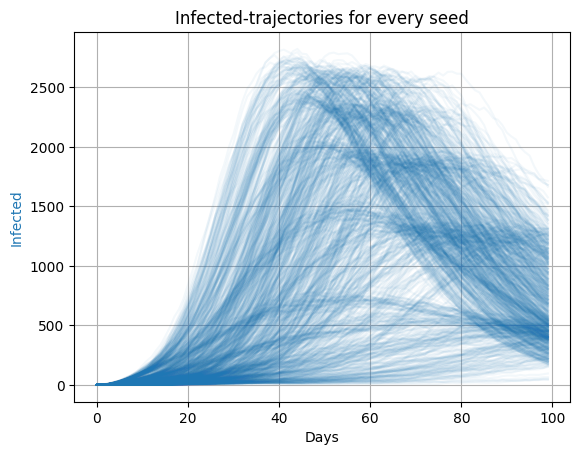

In [17]:
train_csvs = sorted((SPLITS_ROOT / 'train').glob('seir_seed_*.csv'))
for p in train_csvs:
    df = pd.read_csv(p)
    plt.plot(np.arange(0, len(df)), df['I'].values, alpha=0.05, color='tab:blue')
plt.xlabel('Days')
plt.ylabel('Infected', color='tab:blue')
plt.title('Infected-trajectories for every seed')
plt.grid()
plt.show()


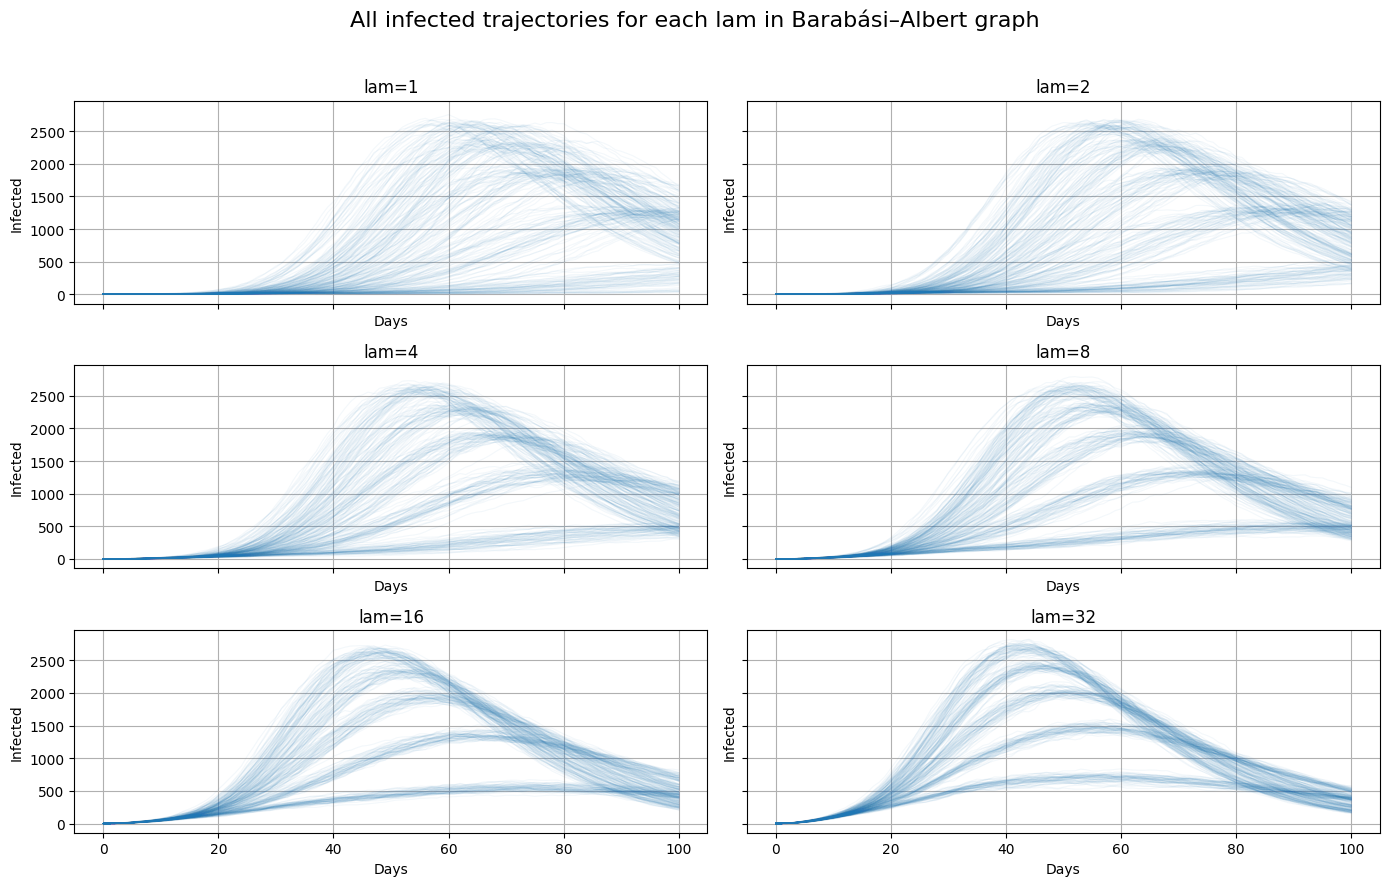

In [20]:
import glob
import os
import math

base_dir = str(SIM_ROOT / 'barabasi_albert_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Barabási–Albert graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


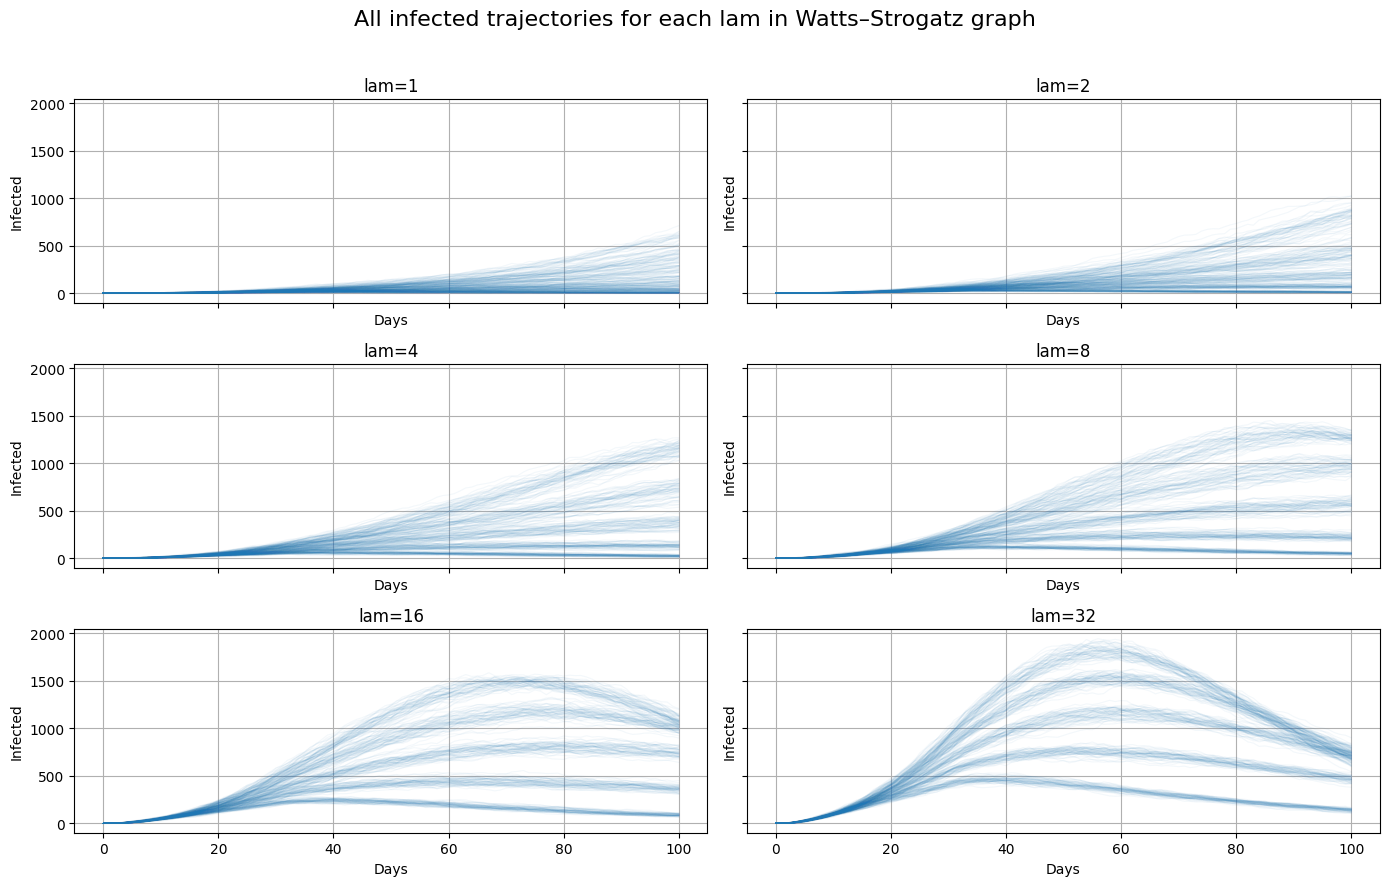

In [23]:
import glob
import os
import math

base_dir = str(SIM_ROOT / 'watts_strogatz_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Watts–Strogatz graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Visualization of different graph types in NetworkX
import networkx as nx
import matplotlib.pyplot as plt

N = 50
seed_layout = 42

# Define different graph types
graphs = {
    'Barabási-Albert\n(m=3)': nx.barabasi_albert_graph(N, 3, seed=seed_layout),
    'Watts-Strogatz\n(k=4, p=0.3)': nx.watts_strogatz_graph(N, 4, 0.3, seed=seed_layout),
    'Complete Graph': nx.complete_graph(N),
    'Cycle Graph': nx.cycle_graph(N),
    'Path Graph': nx.path_graph(N),
    'Star Graph': nx.star_graph(N-1),
    'Wheel Graph': nx.wheel_graph(N),
    'Grid 2D\n(7×7)': nx.grid_2d_graph(7, 7),
    'Ring Lattice\n(k=4)': nx.circulant_graph(N, [1, 2]),
    'Random Geometric\n(radius=0.2)': nx.random_geometric_graph(N, 0.2, seed=seed_layout),
}

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (title, G) in zip(axes, graphs.items()):
    if isinstance(G, nx.MultiGraph) or isinstance(G, nx.MultiDiGraph):
        G = nx.Graph(G)
    
    # Use different layout algorithms for better visualization
    if 'Grid' in title or 'Lattice' in title:
        pos = nx.spring_layout(G, seed=seed_layout, k=0.5, iterations=50)
    else:
        pos = nx.spring_layout(G, seed=seed_layout, k=0.5, iterations=50)
    
    # Draw
    nx.draw(
        G, pos, ax=ax,
        with_labels=False,
        node_color='steelblue',
        edge_color='gray',
        node_size=15 if G.number_of_nodes() > 30 else 30,
        width=0.5,
        alpha=0.8
    )
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Add info
    info_text = f"Nodes: {G.number_of_nodes()}\nEdges: {G.number_of_edges()}"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Different Graph Types in NetworkX', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Stochastic block model

In [ ]:
N = 60
sizes = [15, 25, 20]  # Размеры блоков (групп)
probs = np.array([
    [0.8, 0.1, 0.02],  # Матрица вероятностей соединений между блоками
    [0.1, 0.6, 0.05],
    [0.02, 0.05, 0.4]
])
G = nx.stochastic_block_model(sizes, probs)

colors = ['red', 'blue', 'green']
node_colors = []
for i, size in enumerate(sizes):
    node_colors.extend([colors[i]] * size)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.3)
nx.draw(G, pos,
        node_color=node_colors,
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=10,
                              label=f'Блок {i+1} ({sizes[i]} узлов)')
                  for i in range(len(sizes))]
plt.legend(handles=legend_elements, title='Блоки', loc='upper right')

plt.title('SBM', fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Stochastic Block Model
N = 60
sizes = [15, 25, 20]  # Block sizes (groups)
probs = np.array([
    [0.8, 0.1, 0.02],  # Probability matrix for connections between blocks
    [0.1, 0.6, 0.05],
    [0.02, 0.05, 0.4]
])
G_sbm = nx.stochastic_block_model(sizes, probs)

# Barabási-Albert Graph
G_ba = nx.barabasi_albert_graph(60, 3, seed=42)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# SBM plot
colors = ['red', 'blue', 'green']
node_colors = []
for i, size in enumerate(sizes):
    node_colors.extend([colors[i]] * size)

pos_sbm = nx.spring_layout(G_sbm, seed=42, k=0.3)
nx.draw(G_sbm, pos_sbm, ax=axes[0],
        node_color=node_colors,
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)
axes[0].set_title('Stochastic Block Model')
axes[0].axis('off')

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=10,
                              label=f'Block {i+1} ({sizes[i]} nodes)')
                  for i in range(len(sizes))]
axes[0].legend(handles=legend_elements, title='Blocks', loc='upper right')

# BA plot
pos_ba = nx.spring_layout(G_ba, seed=42, k=0.3)
nx.draw(G_ba, pos_ba, ax=axes[1],
        node_color='steelblue',
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)
axes[1].set_title('Barabási-Albert Graph (N=60, m=3)')
axes[1].axis('off')

info_text = f"Nodes: {G_ba.number_of_nodes()}\nEdges: {G_ba.number_of_edges()}"
axes[1].text(0.02, 0.02, info_text, transform=axes[1].transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comparison of Graph Structures', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
N_vis = 100
seed_layout = 42

G_ba = nx.barabasi_albert_graph(N_vis, 5, seed=seed_layout)
G_complete = nx.complete_graph(N_vis)
G_ws = nx.watts_strogatz_graph(N_vis, 8, 0.1, seed=seed_layout)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

graphs_titles = [
    (G_ba, "Barabási–Albert, m=5", dict(node_size=35, width=0.5)),
    (G_complete, "Complete graph $K_{100}$", dict(node_size=25, width=0.03, edge_color=(0.4, 0.4, 0.4, 0.12))),
    (G_ws, "Watts–Strogatz, k=8, p=0.1", dict(node_size=35, width=0.4)),
]

for ax, (G, title, draw_kw) in zip(axes, graphs_titles):
    pos = nx.spring_layout(G, seed=seed_layout, k=0.35)
    nx.draw(
        G, pos, ax=ax,
        with_labels=False,
        node_color="steelblue",
        edge_color=draw_kw.get("edge_color", "gray"),
        **{k: v for k, v in draw_kw.items() if k != "edge_color"},
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()
